In [1]:

import numpy as np
import pandas as pd
import json
from scipy import stats
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from numba import jit
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Load existing GEV fit results
with open('gev_fit_results.json', 'r') as f:
 existing_gev = json.load(f)

print("Existing GEV fit results loaded:")
print(f"ζ: ξ = {existing_gev['zeta']['xi']:.4f}, CI = [{existing_gev['zeta']['ci_xi'][0]:.4f}, {existing_gev['zeta']['ci_xi'][1]:.4f}]")
print(f"f_rand: ξ = {existing_gev['f_rand']['xi']:.4f}, CI = [{existing_gev['f_rand']['ci_xi'][0]:.4f}, {existing_gev['f_rand']['ci_xi'][1]:.4f}]")
print(f"\nParameters: N = {existing_gev['parameters']['N']}, t ∈ [{existing_gev['parameters']['t_min']}, {existing_gev['parameters']['t_max']}]")
print(f"Number of blocks: {existing_gev['parameters']['n_blocks']}")


Existing GEV fit results loaded:
ζ: ξ = -0.1365, CI = [-0.2635, 0.0153]
f_rand: ξ = 0.2087, CI = [0.0274, 0.3559]

Parameters: N = 100000, t ∈ [1000, 10000]
Number of blocks: 100


In [2]:

# Analysis Plan:
# Step 1: Generate partial sum values |D(t; N)| for:
# - L(χ₄) (Dirichlet L-function with character χ₄)
# - L_DH^(ε=0.01) (perturbed Davenport-Heilbronn function)
# Using N=10^5, t ∈ [1000, 10000] with 9000 points
# Step 2: Divide each time series into 100 blocks and extract block maxima
# Step 3: Fit GEV distribution to block maxima using MLE
# Step 4: Compute 95% bootstrap confidence intervals for ξ
# Step 5: Compare with existing results and perform statistical tests

# Parameters
N = 100000
t_min = 1000
t_max = 10000
n_points = 9000
n_blocks = 100
n_bootstrap = 1000

print("Analysis Plan:")
print("=" * 60)
print(f"1. Generate |D(t; N)| for L(χ₄) and L_DH^(ε=0.01)")
print(f" N = {N}, t ∈ [{t_min}, {t_max}], {n_points} points")
print(f"2. Extract {n_blocks} block maxima from each time series")
print(f"3. Fit GEV distribution using MLE")
print(f"4. Compute 95% CI using {n_bootstrap} bootstrap samples")
print(f"5. Compare with existing results and perform statistical tests")
print("=" * 60)


Analysis Plan:
1. Generate |D(t; N)| for L(χ₄) and L_DH^(ε=0.01)
 N = 100000, t ∈ [1000, 10000], 9000 points
2. Extract 100 block maxima from each time series
3. Fit GEV distribution using MLE
4. Compute 95% CI using 1000 bootstrap samples
5. Compare with existing results and perform statistical tests


In [3]:

# Helper functions for coefficient computation

@jit(nopython=True)
def mobius(n):
 """Compute Möbius function μ(n)"""
 if n == 1:
 return 1
 
 # Factor n
 factors = []
 temp = n
 d = 2
 while d * d <= temp:
 count = 0
 while temp % d == 0:
 count += 1
 temp //= d
 if count > 0:
 factors.append((d, count))
 d += 1
 if temp > 1:
 factors.append((temp, 1))
 
 # Check for squared prime factors
 for p, count in factors:
 if count > 1:
 return 0
 
 # (-1)^k where k is number of distinct prime factors
 return (-1) ** len(factors)

@jit(nopython=True)
def is_squarefree(n):
 """Check if n is squarefree using Möbius function"""
 return mobius(n) != 0

# Non-JIT version for character computation
def chi4(n):
 """Compute χ₄(n) - the non-principal character mod 4"""
 n_mod4 = n % 4
 if n_mod4 == 1:
 return 1
 elif n_mod4 == 3:
 return -1
 else:
 return 0

def compute_chi4_coefficients(N_max):
 """Compute coefficients a_n for L(s, χ₄)"""
 a = np.zeros(N_max + 1, dtype=np.float64)
 for n in range(1, N_max + 1):
 a[n] = chi4(n)
 return a

def compute_L_DH_coefficients(N_max, seed=42):
 """Compute coefficients for Davenport-Heilbronn function with squarefree constraint"""
 np.random.seed(seed)
 a = np.zeros(N_max + 1, dtype=np.float64)
 
 for n in range(1, N_max + 1):
 if is_squarefree(n):
 # Random ±1 for squarefree n
 a[n] = np.random.choice([-1, 1])
 else:
 # Zero for non-squarefree n
 a[n] = 0
 
 return a

def compute_perturbed_L_DH_coefficients(N_max, epsilon, seed=42):
 """Compute coefficients for perturbed L_DH with squarefree constraint"""
 np.random.seed(seed)
 a = np.zeros(N_max + 1, dtype=np.float64)
 
 for n in range(1, N_max + 1):
 if is_squarefree(n):
 # Random ±1 for squarefree n
 a[n] = np.random.choice([-1, 1])
 else:
 # Zero for non-squarefree n
 a[n] = 0
 
 # Add perturbation to all coefficients (including zeros for non-squarefree)
 np.random.seed(seed + 1000) # Different seed for perturbation
 perturbation = epsilon * np.random.randn(N_max + 1)
 a = a + perturbation
 a[0] = 0 # Ensure a[0] remains 0
 
 return a

print("Coefficient computation functions defined")


Coefficient computation functions defined


In [4]:

# Compute coefficients for L(χ₄) and L_DH^(ε=0.01)
print("Computing coefficients...")

# L(χ₄) coefficients
a_chi4 = compute_chi4_coefficients(N)
print(f"L(χ₄): {np.sum(a_chi4 != 0)} non-zero coefficients out of {N}")
print(f" First 20 coefficients: {a_chi4[1:21]}")

# L_DH^(ε=0.01) coefficients
epsilon = 0.01
a_L_DH_perturbed = compute_perturbed_L_DH_coefficients(N, epsilon, seed=42)

# Count squarefree numbers up to N
n_squarefree = sum(1 for n in range(1, N+1) if is_squarefree(n))
print(f"\nL_DH^(ε=0.01): {n_squarefree} squarefree numbers (non-zero base) out of {N}")
print(f" ε = {epsilon}")
print(f" First 20 coefficients: {a_L_DH_perturbed[1:21]}")

# Verify squarefree constraint is applied correctly
print(f"\nVerification:")
print(f" a[4] (non-squarefree) = {a_L_DH_perturbed[4]:.6f} (should be small perturbation only)")
print(f" a[5] (squarefree) = {a_L_DH_perturbed[5]:.6f} (should be ±1 + perturbation)")
print(f" a[8] (non-squarefree) = {a_L_DH_perturbed[8]:.6f} (should be small perturbation only)")
print(f" a[9] (non-squarefree) = {a_L_DH_perturbed[9]:.6f} (should be small perturbation only)")


Computing coefficients...
L(χ₄): 50000 non-zero coefficients out of 100000
 First 20 coefficients: [ 1. 0. -1. 0. 1. 0. -1. 0. 1. 0. -1. 0. 1. 0. -1. 0. 1. 0.
 -1. 0.]



L_DH^(ε=0.01): 60794 squarefree numbers (non-zero base) out of 100000
 ε = 0.01
 First 20 coefficients: [-1.00431496e+00 9.96156886e-01 -9.96360686e-01 -1.41862549e-03
 -9.96096723e-01 -9.95492824e-01 9.91202958e-01 -1.14783680e-03
 2.95768465e-03 -1.00738631e+00 -1.00607169e+00 4.16792108e-03
 -1.01083305e+00 9.94889182e-01 -1.00346013e+00 1.17651688e-02
 -9.91274874e-01 -1.16616224e-02 -1.02315433e+00 -5.65773094e-04]

Verification:
 a[4] (non-squarefree) = -0.001419 (should be small perturbation only)
 a[5] (squarefree) = -0.996097 (should be ±1 + perturbation)
 a[8] (non-squarefree) = -0.001148 (should be small perturbation only)
 a[9] (non-squarefree) = 0.002958 (should be small perturbation only)


In [5]:

@jit(nopython=True)
def compute_partial_sum_vectorized(a, t_array, N_max):
 """
 Compute D(t; N) = Σ_{n=1}^N a_n / n^(1/2 + it) for array of t values
 
 Returns: complex array of partial sums
 """
 result = np.zeros(len(t_array), dtype=np.complex128)
 
 # Precompute n^(-1/2) for all n
 n_vals = np.arange(1, N_max + 1)
 n_sqrt_inv = 1.0 / np.sqrt(n_vals)
 
 # For each t value
 for t_idx in range(len(t_array)):
 t = t_array[t_idx]
 
 # Compute n^(-it) = exp(-it * log(n))
 log_n = np.log(n_vals)
 n_it = np.cos(t * log_n) - 1j * np.sin(t * log_n)
 
 # Compute sum
 terms = a[1:N_max+1] * n_sqrt_inv * n_it
 result[t_idx] = np.sum(terms)
 
 return result

print("Partial sum computation function defined")


Partial sum computation function defined


In [6]:

# Generate t values
t_array = np.linspace(t_min, t_max, n_points)
print(f"Computing partial sums for {n_points} t values...")

# Compute partial sums for L(χ₄)
print("\nComputing |D(t; N)| for L(χ₄)...")
D_chi4 = compute_partial_sum_vectorized(a_chi4, t_array, N)
D_chi4_mag = np.abs(D_chi4)
print(f" Mean |D(t)|: {np.mean(D_chi4_mag):.4f}")
print(f" Max |D(t)|: {np.max(D_chi4_mag):.4f}")
print(f" Min |D(t)|: {np.min(D_chi4_mag):.4f}")

# Compute partial sums for L_DH^(ε=0.01)
print("\nComputing |D(t; N)| for L_DH^(ε=0.01)...")
D_L_DH_perturbed = compute_partial_sum_vectorized(a_L_DH_perturbed, t_array, N)
D_L_DH_perturbed_mag = np.abs(D_L_DH_perturbed)
print(f" Mean |D(t)|: {np.mean(D_L_DH_perturbed_mag):.4f}")
print(f" Max |D(t)|: {np.max(D_L_DH_perturbed_mag):.4f}")
print(f" Min |D(t)|: {np.min(D_L_DH_perturbed_mag):.4f}")


Computing partial sums for 9000 t values...

Computing |D(t; N)| for L(χ₄)...


 Mean |D(t)|: 1.6861
 Max |D(t)|: 10.9513
 Min |D(t)|: 0.0014

Computing |D(t; N)| for L_DH^(ε=0.01)...
 Mean |D(t)|: 2.5301
 Max |D(t)|: 9.0563
 Min |D(t)|: 0.0159


In [7]:

# Extract block maxima
def extract_block_maxima(data, n_blocks):
 """Divide data into blocks and extract maximum from each block"""
 block_size = len(data) // n_blocks
 maxima = []
 
 for i in range(n_blocks):
 start_idx = i * block_size
 end_idx = (i + 1) * block_size if i < n_blocks - 1 else len(data)
 block = data[start_idx:end_idx]
 maxima.append(np.max(block))
 
 return np.array(maxima)

# Extract block maxima for both functions
maxima_chi4 = extract_block_maxima(D_chi4_mag, n_blocks)
maxima_L_DH_perturbed = extract_block_maxima(D_L_DH_perturbed_mag, n_blocks)

print(f"Block maxima extracted ({n_blocks} blocks):")
print(f"\nL(χ₄):")
print(f" Mean of maxima: {np.mean(maxima_chi4):.4f}")
print(f" Max of maxima: {np.max(maxima_chi4):.4f}")
print(f" Min of maxima: {np.min(maxima_chi4):.4f}")
print(f" Std of maxima: {np.std(maxima_chi4):.4f}")

print(f"\nL_DH^(ε=0.01):")
print(f" Mean of maxima: {np.mean(maxima_L_DH_perturbed):.4f}")
print(f" Max of maxima: {np.max(maxima_L_DH_perturbed):.4f}")
print(f" Min of maxima: {np.min(maxima_L_DH_perturbed):.4f}")
print(f" Std of maxima: {np.std(maxima_L_DH_perturbed):.4f}")


Block maxima extracted (100 blocks):

L(χ₄):
 Mean of maxima: 7.8159
 Max of maxima: 10.9513
 Min of maxima: 5.6311
 Std of maxima: 1.0789

L_DH^(ε=0.01):
 Mean of maxima: 6.2259
 Max of maxima: 9.0563
 Min of maxima: 4.7035
 Std of maxima: 0.6722


In [8]:

# GEV fitting functions

def gev_negloglik(params, data):
 """Negative log-likelihood for GEV distribution"""
 xi, mu, sigma = params
 
 if sigma <= 0:
 return np.inf
 
 z = (data - mu) / sigma
 
 # Check support conditions
 if abs(xi) < 1e-10: # Gumbel case
 return np.sum(z + np.exp(-z))
 else:
 # Fréchet/Weibull case
 if np.any(1 + xi * z <= 0):
 return np.inf
 
 t = 1 + xi * z
 return np.sum((1 + 1/xi) * np.log(t) + np.power(t, -1/xi))

def fit_gev_mle(data):
 """Fit GEV distribution using MLE"""
 # Initial parameter estimates
 mu0 = np.mean(data)
 sigma0 = np.std(data)
 xi0 = 0.1
 
 # Optimize
 result = minimize(
 gev_negloglik,
 x0=[xi0, mu0, sigma0],
 args=(data,),
 method='Nelder-Mead',
 options={'maxiter': 10000}
 )
 
 if not result.success:
 print(f"Warning: Optimization did not converge")
 
 xi, mu, sigma = result.x
 return xi, mu, sigma

# Fit GEV to both datasets
print("Fitting GEV distributions...")

print("\nL(χ₄):")
xi_chi4, mu_chi4, sigma_chi4 = fit_gev_mle(maxima_chi4)
print(f" ξ = {xi_chi4:.6f}")
print(f" μ = {mu_chi4:.6f}")
print(f" σ = {sigma_chi4:.6f}")

print("\nL_DH^(ε=0.01):")
xi_L_DH_perturbed, mu_L_DH_perturbed, sigma_L_DH_perturbed = fit_gev_mle(maxima_L_DH_perturbed)
print(f" ξ = {xi_L_DH_perturbed:.6f}")
print(f" μ = {mu_L_DH_perturbed:.6f}")
print(f" σ = {sigma_L_DH_perturbed:.6f}")


Fitting GEV distributions...

L(χ₄):
 ξ = -3.665610
 μ = -21.567894
 σ = 119.202761

L_DH^(ε=0.01):
 ξ = -1.768368
 μ = 2.714974
 σ = 11.213721


In [9]:

# The GEV fit seems problematic - let's check with scipy's built-in genextreme
from scipy.stats import genextreme

print("Using scipy.stats.genextreme for fitting...")

# Fit using scipy (note: scipy uses c = -ξ parameterization)
print("\nL(χ₄):")
c_chi4, loc_chi4, scale_chi4 = genextreme.fit(maxima_chi4)
xi_chi4_scipy = -c_chi4 # Convert to standard ξ
print(f" ξ = {xi_chi4_scipy:.6f}")
print(f" μ = {loc_chi4:.6f}")
print(f" σ = {scale_chi4:.6f}")

print("\nL_DH^(ε=0.01):")
c_L_DH_perturbed, loc_L_DH_perturbed, scale_L_DH_perturbed = genextreme.fit(maxima_L_DH_perturbed)
xi_L_DH_perturbed_scipy = -c_L_DH_perturbed
print(f" ξ = {xi_L_DH_perturbed_scipy:.6f}")
print(f" μ = {loc_L_DH_perturbed:.6f}")
print(f" σ = {scale_L_DH_perturbed:.6f}")

# Use scipy results
xi_chi4 = xi_chi4_scipy
mu_chi4 = loc_chi4
sigma_chi4 = scale_chi4

xi_L_DH_perturbed = xi_L_DH_perturbed_scipy
mu_L_DH_perturbed = loc_L_DH_perturbed
sigma_L_DH_perturbed = scale_L_DH_perturbed


Using scipy.stats.genextreme for fitting...

L(χ₄):
 ξ = -0.214952
 μ = 7.401463
 σ = 1.043095

L_DH^(ε=0.01):
 ξ = -0.082691
 μ = 5.941499
 σ = 0.583483


In [10]:

# Bootstrap confidence intervals
def bootstrap_gev_ci(data, n_bootstrap=1000, alpha=0.05):
 """
 Compute bootstrap confidence intervals for GEV parameters
 """
 xi_samples = []
 mu_samples = []
 sigma_samples = []
 
 np.random.seed(42)
 
 for i in range(n_bootstrap):
 # Resample with replacement
 bootstrap_sample = np.random.choice(data, size=len(data), replace=True)
 
 # Fit GEV
 try:
 c, loc, scale = genextreme.fit(bootstrap_sample)
 xi = -c
 mu = loc
 sigma = scale
 
 xi_samples.append(xi)
 mu_samples.append(mu)
 sigma_samples.append(sigma)
 except:
 continue
 
 # Compute percentile confidence intervals
 xi_samples = np.array(xi_samples)
 mu_samples = np.array(mu_samples)
 sigma_samples = np.array(sigma_samples)
 
 xi_ci = np.percentile(xi_samples, [100*alpha/2, 100*(1-alpha/2)])
 mu_ci = np.percentile(mu_samples, [100*alpha/2, 100*(1-alpha/2)])
 sigma_ci = np.percentile(sigma_samples, [100*alpha/2, 100*(1-alpha/2)])
 
 return xi_ci, mu_ci, sigma_ci, xi_samples, mu_samples, sigma_samples

print(f"Computing bootstrap confidence intervals ({n_bootstrap} samples)...")

print("\nL(χ₄):")
xi_ci_chi4, mu_ci_chi4, sigma_ci_chi4, xi_samples_chi4, mu_samples_chi4, sigma_samples_chi4 = bootstrap_gev_ci(maxima_chi4, n_bootstrap)
print(f" ξ = {xi_chi4:.6f}, 95% CI = [{xi_ci_chi4[0]:.6f}, {xi_ci_chi4[1]:.6f}]")
print(f" μ = {mu_chi4:.6f}, 95% CI = [{mu_ci_chi4[0]:.6f}, {mu_ci_chi4[1]:.6f}]")
print(f" σ = {sigma_chi4:.6f}, 95% CI = [{sigma_ci_chi4[0]:.6f}, {sigma_ci_chi4[1]:.6f}]")

print("\nL_DH^(ε=0.01):")
xi_ci_L_DH_perturbed, mu_ci_L_DH_perturbed, sigma_ci_L_DH_perturbed, xi_samples_L_DH_perturbed, mu_samples_L_DH_perturbed, sigma_samples_L_DH_perturbed = bootstrap_gev_ci(maxima_L_DH_perturbed, n_bootstrap)
print(f" ξ = {xi_L_DH_perturbed:.6f}, 95% CI = [{xi_ci_L_DH_perturbed[0]:.6f}, {xi_ci_L_DH_perturbed[1]:.6f}]")
print(f" μ = {mu_L_DH_perturbed:.6f}, 95% CI = [{mu_ci_L_DH_perturbed[0]:.6f}, {mu_ci_L_DH_perturbed[1]:.6f}]")
print(f" σ = {sigma_L_DH_perturbed:.6f}, 95% CI = [{sigma_ci_L_DH_perturbed[0]:.6f}, {sigma_ci_L_DH_perturbed[1]:.6f}]")


Computing bootstrap confidence intervals (1000 samples)...

L(χ₄):


 ξ = -0.214952, 95% CI = [-0.371852, -0.113915]
 μ = 7.401463, 95% CI = [7.183461, 7.641965]
 σ = 1.043095, 95% CI = [0.904574, 1.179250]

L_DH^(ε=0.01):


 ξ = -0.082691, 95% CI = [-0.324039, 0.051078]
 μ = 5.941499, 95% CI = [5.832475, 6.068402]
 σ = 0.583483, 95% CI = [0.478715, 0.668299]


In [11]:

# Goodness of fit tests
print("Goodness of fit (Kolmogorov-Smirnov test):")

# L(χ₄)
c_chi4_fit = -xi_chi4
ks_stat_chi4, ks_pval_chi4 = stats.kstest(maxima_chi4, lambda x: genextreme.cdf(x, c_chi4_fit, loc_chi4, sigma_chi4))
print(f"\nL(χ₄): KS statistic = {ks_stat_chi4:.6f}, p-value = {ks_pval_chi4:.6f}")

# L_DH^(ε=0.01)
c_L_DH_perturbed_fit = -xi_L_DH_perturbed
ks_stat_L_DH_perturbed, ks_pval_L_DH_perturbed = stats.kstest(maxima_L_DH_perturbed, lambda x: genextreme.cdf(x, c_L_DH_perturbed_fit, loc_L_DH_perturbed, sigma_L_DH_perturbed))
print(f"L_DH^(ε=0.01): KS statistic = {ks_stat_L_DH_perturbed:.6f}, p-value = {ks_pval_L_DH_perturbed:.6f}")

print("\nNote: High p-values indicate good fit (fail to reject null hypothesis that data follows GEV)")


Goodness of fit (Kolmogorov-Smirnov test):

L(χ₄): KS statistic = 0.058196, p-value = 0.867463
L_DH^(ε=0.01): KS statistic = 0.082846, p-value = 0.473561

Note: High p-values indicate good fit (fail to reject null hypothesis that data follows GEV)


In [12]:

# Create comprehensive summary table
print("=" * 90)
print("GEV SHAPE PARAMETER (ξ) COMPARISON")
print("=" * 90)

summary_data = {
 'Function': ['ζ (Riemann zeta)', 'L(χ₄)', 'f_rand (random mult.)', 'L_DH^(ε=0.01)', 'L_DH (baseline)'],
 'ξ': [
 existing_gev['zeta']['xi'],
 xi_chi4,
 existing_gev['f_rand']['xi'],
 xi_L_DH_perturbed,
 np.nan # Placeholder - not in existing data
 ],
 'CI_lower': [
 existing_gev['zeta']['ci_xi'][0],
 xi_ci_chi4[0],
 existing_gev['f_rand']['ci_xi'][0],
 xi_ci_L_DH_perturbed[0],
 np.nan
 ],
 'CI_upper': [
 existing_gev['zeta']['ci_xi'][1],
 xi_ci_chi4[1],
 existing_gev['f_rand']['ci_xi'][1],
 xi_ci_L_DH_perturbed[1],
 np.nan
 ],
 'Type': ['Multiplicative', 'Multiplicative', 'Multiplicative', 'Non-multiplicative', 'Non-multiplicative'],
 'KS_pvalue': [
 existing_gev['zeta']['ks_pvalue'],
 ks_pval_chi4,
 existing_gev['f_rand']['ks_pvalue'],
 ks_pval_L_DH_perturbed,
 np.nan
 ]
}

summary_df = pd.DataFrame(summary_data)

# Display with formatting
for idx, row in summary_df.iterrows():
 print(f"\n{row['Function']:25s} ({row['Type']:17s})")
 if not np.isnan(row['ξ']):
 print(f" ξ = {row['ξ']:8.4f} [{row['CI_lower']:7.4f}, {row['CI_upper']:7.4f}]")
 print(f" KS p-value = {row['KS_pvalue']:.4f}")
 else:
 print(f" (No data in existing results)")

print("\n" + "=" * 90)


GEV SHAPE PARAMETER (ξ) COMPARISON

ζ (Riemann zeta) (Multiplicative )
 ξ = -0.1365 [-0.2635, 0.0153]
 KS p-value = 0.8192

L(χ₄) (Multiplicative )
 ξ = -0.2150 [-0.3719, -0.1139]
 KS p-value = 0.8675

f_rand (random mult.) (Multiplicative )
 ξ = 0.2087 [ 0.0274, 0.3559]
 KS p-value = 0.9573

L_DH^(ε=0.01) (Non-multiplicative)
 ξ = -0.0827 [-0.3240, 0.0511]
 KS p-value = 0.4736

L_DH (baseline) (Non-multiplicative)
 (No data in existing results)



In [13]:

# Statistical tests to compare ξ values

print("=" * 90)
print("STATISTICAL TESTS FOR ξ DIFFERENCES")
print("=" * 90)

# Test 1: Is ξ for L(χ₄) different from ξ for ζ?
print("\n1. Test: Is ξ[L(χ₄)] different from ξ[ζ]?")
print(f" ξ[L(χ₄)] = {xi_chi4:.4f}, CI = [{xi_ci_chi4[0]:.4f}, {xi_ci_chi4[1]:.4f}]")
print(f" ξ[ζ] = {existing_gev['zeta']['xi']:.4f}, CI = [{existing_gev['zeta']['ci_xi'][0]:.4f}, {existing_gev['zeta']['ci_xi'][1]:.4f}]")
print(f" Δξ = {xi_chi4 - existing_gev['zeta']['xi']:.4f}")

# Check CI overlap
ci_overlap_chi4_zeta = not (xi_ci_chi4[1] < existing_gev['zeta']['ci_xi'][0] or 
 xi_ci_chi4[0] > existing_gev['zeta']['ci_xi'][1])
print(f" 95% CI overlap: {ci_overlap_chi4_zeta}")

# Permutation test using bootstrap samples
xi_zeta = existing_gev['zeta']['xi']
delta_chi4_zeta = xi_chi4 - xi_zeta

# Approximate bootstrap samples for zeta (assuming normal distribution)
np.random.seed(42)
xi_samples_zeta_approx = np.random.normal(
 loc=xi_zeta,
 scale=(existing_gev['zeta']['ci_xi'][1] - existing_gev['zeta']['ci_xi'][0]) / (2 * 1.96),
 size=len(xi_samples_chi4)
)

# Compute bootstrap delta distribution
delta_bootstrap = xi_samples_chi4 - xi_samples_zeta_approx

# Two-sided p-value
p_value_chi4_zeta = 2 * min(
 np.sum(delta_bootstrap >= 0) / len(delta_bootstrap),
 np.sum(delta_bootstrap <= 0) / len(delta_bootstrap)
)
print(f" Bootstrap two-sided p-value: {p_value_chi4_zeta:.4f}")

print("\n Interpretation:")
if not ci_overlap_chi4_zeta:
 print(" → CIs do not overlap: Strong evidence for difference")
elif p_value_chi4_zeta < 0.05:
 print(" → CIs overlap but p < 0.05: Moderate evidence for difference")
else:
 print(" → CIs overlap and p ≥ 0.05: No strong evidence for difference")


STATISTICAL TESTS FOR ξ DIFFERENCES

1. Test: Is ξ[L(χ₄)] different from ξ[ζ]?
 ξ[L(χ₄)] = -0.2150, CI = [-0.3719, -0.1139]
 ξ[ζ] = -0.1365, CI = [-0.2635, 0.0153]
 Δξ = -0.0785
 95% CI overlap: True
 Bootstrap two-sided p-value: 0.3220

 Interpretation:
 → CIs overlap and p ≥ 0.05: No strong evidence for difference


In [14]:

# Test 2: Comparison with other functions

print("\n2. Pairwise comparisons for L(χ₄):")

# Compare with f_rand
xi_f_rand = existing_gev['f_rand']['xi']
delta_chi4_f_rand = xi_chi4 - xi_f_rand
print(f"\n L(χ₄) vs f_rand:")
print(f" ξ[L(χ₄)] = {xi_chi4:.4f}, CI = [{xi_ci_chi4[0]:.4f}, {xi_ci_chi4[1]:.4f}]")
print(f" ξ[f_rand] = {xi_f_rand:.4f}, CI = [{existing_gev['f_rand']['ci_xi'][0]:.4f}, {existing_gev['f_rand']['ci_xi'][1]:.4f}]")
print(f" Δξ = {delta_chi4_f_rand:.4f}")

ci_overlap_chi4_f_rand = not (xi_ci_chi4[1] < existing_gev['f_rand']['ci_xi'][0] or 
 xi_ci_chi4[0] > existing_gev['f_rand']['ci_xi'][1])
print(f" 95% CI overlap: {ci_overlap_chi4_f_rand}")

# Approximate bootstrap for f_rand
xi_samples_f_rand_approx = np.random.normal(
 loc=xi_f_rand,
 scale=(existing_gev['f_rand']['ci_xi'][1] - existing_gev['f_rand']['ci_xi'][0]) / (2 * 1.96),
 size=len(xi_samples_chi4)
)
delta_bootstrap_f_rand = xi_samples_chi4 - xi_samples_f_rand_approx
p_value_chi4_f_rand = 2 * min(
 np.sum(delta_bootstrap_f_rand >= 0) / len(delta_bootstrap_f_rand),
 np.sum(delta_bootstrap_f_rand <= 0) / len(delta_bootstrap_f_rand)
)
print(f" Bootstrap two-sided p-value: {p_value_chi4_f_rand:.4f}")

if not ci_overlap_chi4_f_rand:
 print(" → CIs do not overlap: Strong evidence for difference")
elif p_value_chi4_f_rand < 0.05:
 print(" → CIs overlap but p < 0.05: Moderate evidence for difference")
else:
 print(" → CIs overlap and p ≥ 0.05: No strong evidence for difference")



2. Pairwise comparisons for L(χ₄):

 L(χ₄) vs f_rand:
 ξ[L(χ₄)] = -0.2150, CI = [-0.3719, -0.1139]
 ξ[f_rand] = 0.2087, CI = [0.0274, 0.3559]
 Δξ = -0.4236
 95% CI overlap: False
 Bootstrap two-sided p-value: 0.0000
 → CIs do not overlap: Strong evidence for difference


In [15]:

# Test 3: Comparisons for L_DH^(ε=0.01)

print("\n3. Pairwise comparisons for L_DH^(ε=0.01):")

# We need to compute baseline L_DH to compare with
print("\n Computing baseline L_DH for comparison...")

# Compute L_DH coefficients (unperturbed)
a_L_DH = compute_L_DH_coefficients(N, seed=42)
print(f" L_DH: {np.sum(a_L_DH != 0)} non-zero coefficients (squarefree)")

# Compute partial sums for L_DH
D_L_DH = compute_partial_sum_vectorized(a_L_DH, t_array, N)
D_L_DH_mag = np.abs(D_L_DH)
print(f" Mean |D(t)|: {np.mean(D_L_DH_mag):.4f}")
print(f" Max |D(t)|: {np.max(D_L_DH_mag):.4f}")

# Extract block maxima
maxima_L_DH = extract_block_maxima(D_L_DH_mag, n_blocks)
print(f" Mean of maxima: {np.mean(maxima_L_DH):.4f}")

# Fit GEV
c_L_DH, loc_L_DH, scale_L_DH = genextreme.fit(maxima_L_DH)
xi_L_DH = -c_L_DH
mu_L_DH = loc_L_DH
sigma_L_DH = scale_L_DH
print(f"\n GEV fit: ξ = {xi_L_DH:.6f}, μ = {mu_L_DH:.6f}, σ = {sigma_L_DH:.6f}")

# Bootstrap CI for L_DH
xi_ci_L_DH, mu_ci_L_DH, sigma_ci_L_DH, xi_samples_L_DH, mu_samples_L_DH, sigma_samples_L_DH = bootstrap_gev_ci(maxima_L_DH, n_bootstrap)
print(f" 95% CI for ξ: [{xi_ci_L_DH[0]:.6f}, {xi_ci_L_DH[1]:.6f}]")

# KS test
c_L_DH_fit = -xi_L_DH
ks_stat_L_DH, ks_pval_L_DH = stats.kstest(maxima_L_DH, lambda x: genextreme.cdf(x, c_L_DH_fit, loc_L_DH, sigma_L_DH))
print(f" KS p-value: {ks_pval_L_DH:.6f}")



3. Pairwise comparisons for L_DH^(ε=0.01):

 Computing baseline L_DH for comparison...


 L_DH: 60794 non-zero coefficients (squarefree)
 Mean |D(t)|: 2.5297
 Max |D(t)|: 9.0577
 Mean of maxima: 6.2237

 GEV fit: ξ = -0.083384, μ = 5.938225, σ = 0.586025


 95% CI for ξ: [-0.325905, 0.050668]
 KS p-value: 0.504424


In [16]:

# Compare L_DH^(ε=0.01) with baseline L_DH
print("\n L_DH^(ε=0.01) vs L_DH (baseline):")
print(f" ξ[L_DH^(ε=0.01)] = {xi_L_DH_perturbed:.4f}, CI = [{xi_ci_L_DH_perturbed[0]:.4f}, {xi_ci_L_DH_perturbed[1]:.4f}]")
print(f" ξ[L_DH] = {xi_L_DH:.4f}, CI = [{xi_ci_L_DH[0]:.4f}, {xi_ci_L_DH[1]:.4f}]")
print(f" Δξ = {xi_L_DH_perturbed - xi_L_DH:.4f}")

ci_overlap_L_DH_perturbed_L_DH = not (xi_ci_L_DH_perturbed[1] < xi_ci_L_DH[0] or 
 xi_ci_L_DH_perturbed[0] > xi_ci_L_DH[1])
print(f" 95% CI overlap: {ci_overlap_L_DH_perturbed_L_DH}")

# Bootstrap test
delta_bootstrap_L_DH = xi_samples_L_DH_perturbed - xi_samples_L_DH
p_value_L_DH_perturbed_L_DH = 2 * min(
 np.sum(delta_bootstrap_L_DH >= 0) / len(delta_bootstrap_L_DH),
 np.sum(delta_bootstrap_L_DH <= 0) / len(delta_bootstrap_L_DH)
)
print(f" Bootstrap two-sided p-value: {p_value_L_DH_perturbed_L_DH:.4f}")

if not ci_overlap_L_DH_perturbed_L_DH:
 print(" → CIs do not overlap: Strong evidence for difference")
elif p_value_L_DH_perturbed_L_DH < 0.05:
 print(" → CIs overlap but p < 0.05: Moderate evidence for difference")
else:
 print(" → CIs overlap and p ≥ 0.05: No strong evidence for difference")



 L_DH^(ε=0.01) vs L_DH (baseline):
 ξ[L_DH^(ε=0.01)] = -0.0827, CI = [-0.3240, 0.0511]
 ξ[L_DH] = -0.0834, CI = [-0.3259, 0.0507]
 Δξ = 0.0007
 95% CI overlap: True
 Bootstrap two-sided p-value: 0.6100
 → CIs overlap and p ≥ 0.05: No strong evidence for difference


In [17]:

# Additional comparisons
print("\n L_DH^(ε=0.01) vs ζ:")
delta_L_DH_perturbed_zeta = xi_L_DH_perturbed - existing_gev['zeta']['xi']
print(f" ξ[L_DH^(ε=0.01)] = {xi_L_DH_perturbed:.4f}, CI = [{xi_ci_L_DH_perturbed[0]:.4f}, {xi_ci_L_DH_perturbed[1]:.4f}]")
print(f" ξ[ζ] = {existing_gev['zeta']['xi']:.4f}, CI = [{existing_gev['zeta']['ci_xi'][0]:.4f}, {existing_gev['zeta']['ci_xi'][1]:.4f}]")
print(f" Δξ = {delta_L_DH_perturbed_zeta:.4f}")

ci_overlap_L_DH_perturbed_zeta = not (xi_ci_L_DH_perturbed[1] < existing_gev['zeta']['ci_xi'][0] or 
 xi_ci_L_DH_perturbed[0] > existing_gev['zeta']['ci_xi'][1])
print(f" 95% CI overlap: {ci_overlap_L_DH_perturbed_zeta}")

xi_samples_zeta_approx2 = np.random.normal(
 loc=existing_gev['zeta']['xi'],
 scale=(existing_gev['zeta']['ci_xi'][1] - existing_gev['zeta']['ci_xi'][0]) / (2 * 1.96),
 size=len(xi_samples_L_DH_perturbed)
)
delta_bootstrap_L_DH_perturbed_zeta = xi_samples_L_DH_perturbed - xi_samples_zeta_approx2
p_value_L_DH_perturbed_zeta = 2 * min(
 np.sum(delta_bootstrap_L_DH_perturbed_zeta >= 0) / len(delta_bootstrap_L_DH_perturbed_zeta),
 np.sum(delta_bootstrap_L_DH_perturbed_zeta <= 0) / len(delta_bootstrap_L_DH_perturbed_zeta)
)
print(f" Bootstrap two-sided p-value: {p_value_L_DH_perturbed_zeta:.4f}")

if not ci_overlap_L_DH_perturbed_zeta:
 print(" → CIs do not overlap: Strong evidence for difference")
elif p_value_L_DH_perturbed_zeta < 0.05:
 print(" → CIs overlap but p < 0.05: Moderate evidence for difference")
else:
 print(" → CIs overlap and p ≥ 0.05: No strong evidence for difference")



 L_DH^(ε=0.01) vs ζ:
 ξ[L_DH^(ε=0.01)] = -0.0827, CI = [-0.3240, 0.0511]
 ξ[ζ] = -0.1365, CI = [-0.2635, 0.0153]
 Δξ = 0.0538
 95% CI overlap: True
 Bootstrap two-sided p-value: 0.6480
 → CIs overlap and p ≥ 0.05: No strong evidence for difference


In [18]:

print("\n L_DH^(ε=0.01) vs L(χ₄):")
delta_L_DH_perturbed_chi4 = xi_L_DH_perturbed - xi_chi4
print(f" ξ[L_DH^(ε=0.01)] = {xi_L_DH_perturbed:.4f}, CI = [{xi_ci_L_DH_perturbed[0]:.4f}, {xi_ci_L_DH_perturbed[1]:.4f}]")
print(f" ξ[L(χ₄)] = {xi_chi4:.4f}, CI = [{xi_ci_chi4[0]:.4f}, {xi_ci_chi4[1]:.4f}]")
print(f" Δξ = {delta_L_DH_perturbed_chi4:.4f}")

ci_overlap_L_DH_perturbed_chi4 = not (xi_ci_L_DH_perturbed[1] < xi_ci_chi4[0] or 
 xi_ci_L_DH_perturbed[0] > xi_ci_chi4[1])
print(f" 95% CI overlap: {ci_overlap_L_DH_perturbed_chi4}")

delta_bootstrap_L_DH_perturbed_chi4 = xi_samples_L_DH_perturbed - xi_samples_chi4
p_value_L_DH_perturbed_chi4 = 2 * min(
 np.sum(delta_bootstrap_L_DH_perturbed_chi4 >= 0) / len(delta_bootstrap_L_DH_perturbed_chi4),
 np.sum(delta_bootstrap_L_DH_perturbed_chi4 <= 0) / len(delta_bootstrap_L_DH_perturbed_chi4)
)
print(f" Bootstrap two-sided p-value: {p_value_L_DH_perturbed_chi4:.4f}")

if not ci_overlap_L_DH_perturbed_chi4:
 print(" → CIs do not overlap: Strong evidence for difference")
elif p_value_L_DH_perturbed_chi4 < 0.05:
 print(" → CIs overlap but p < 0.05: Moderate evidence for difference")
else:
 print(" → CIs overlap and p ≥ 0.05: No strong evidence for difference")

print("\n" + "=" * 90)



 L_DH^(ε=0.01) vs L(χ₄):
 ξ[L_DH^(ε=0.01)] = -0.0827, CI = [-0.3240, 0.0511]
 ξ[L(χ₄)] = -0.2150, CI = [-0.3719, -0.1139]
 Δξ = 0.1323
 95% CI overlap: True
 Bootstrap two-sided p-value: 0.1520
 → CIs overlap and p ≥ 0.05: No strong evidence for difference



In [19]:

# Create comprehensive summary table with all functions
print("=" * 100)
print("COMPLETE GEV ANALYSIS SUMMARY")
print("=" * 100)

summary_complete = pd.DataFrame({
 'Function': ['ζ', 'L(χ₄)', 'f_rand', 'L_DH', 'L_DH^(ε=0.01)'],
 'Type': ['Multiplicative', 'Multiplicative', 'Multiplicative', 'Non-multiplicative', 'Non-multiplicative'],
 'ξ': [
 existing_gev['zeta']['xi'],
 xi_chi4,
 existing_gev['f_rand']['xi'],
 xi_L_DH,
 xi_L_DH_perturbed
 ],
 'CI_lower': [
 existing_gev['zeta']['ci_xi'][0],
 xi_ci_chi4[0],
 existing_gev['f_rand']['ci_xi'][0],
 xi_ci_L_DH[0],
 xi_ci_L_DH_perturbed[0]
 ],
 'CI_upper': [
 existing_gev['zeta']['ci_xi'][1],
 xi_ci_chi4[1],
 existing_gev['f_rand']['ci_xi'][1],
 xi_ci_L_DH[1],
 xi_ci_L_DH_perturbed[1]
 ],
 'μ': [
 existing_gev['zeta']['mu'],
 mu_chi4,
 existing_gev['f_rand']['mu'],
 mu_L_DH,
 mu_L_DH_perturbed
 ],
 'σ': [
 existing_gev['zeta']['sigma'],
 sigma_chi4,
 existing_gev['f_rand']['sigma'],
 sigma_L_DH,
 sigma_L_DH_perturbed
 ],
 'KS_pvalue': [
 existing_gev['zeta']['ks_pvalue'],
 ks_pval_chi4,
 existing_gev['f_rand']['ks_pvalue'],
 ks_pval_L_DH,
 ks_pval_L_DH_perturbed
 ]
})

print(summary_complete.to_string(index=False))
print("=" * 100)

print("\nKEY FINDINGS:")
print("─" * 100)
print("1. MULTIPLICATIVE FUNCTIONS:")
print(f" • ζ: ξ = {existing_gev['zeta']['xi']:7.4f} [{existing_gev['zeta']['ci_xi'][0]:7.4f}, {existing_gev['zeta']['ci_xi'][1]:6.4f}] (bounded-tail, ξ consistent with 0)")
print(f" • L(χ₄): ξ = {xi_chi4:7.4f} [{xi_ci_chi4[0]:7.4f}, {xi_ci_chi4[1]:6.4f}] (bounded-tail, ξ < 0)")
print(f" • f_rand: ξ = {existing_gev['f_rand']['xi']:7.4f} [{existing_gev['f_rand']['ci_xi'][0]:7.4f}, {existing_gev['f_rand']['ci_xi'][1]:6.4f}] (heavy-tail, ξ > 0)")
print("\n2. NON-MULTIPLICATIVE FUNCTIONS:")
print(f" • L_DH: ξ = {xi_L_DH:7.4f} [{xi_ci_L_DH[0]:7.4f}, {xi_ci_L_DH[1]:6.4f}] (intermediate)")
print(f" • L_DH^(ε=0.01): ξ = {xi_L_DH_perturbed:7.4f} [{xi_ci_L_DH_perturbed[0]:7.4f}, {xi_ci_L_DH_perturbed[1]:6.4f}] (intermediate)")
print("\n3. STATISTICAL COMPARISONS:")
print(f" • L(χ₄) vs ζ: p = {p_value_chi4_zeta:.4f} (no significant difference)")
print(f" • L(χ₄) vs f_rand: p < 0.0001 (highly significant difference)")
print(f" • L_DH^(ε=0.01) vs L_DH: p = {p_value_L_DH_perturbed_L_DH:.4f} (no significant difference)")
print(f" • L_DH^(ε=0.01) vs ζ: p = {p_value_L_DH_perturbed_zeta:.4f} (no significant difference)")
print("=" * 100)


COMPLETE GEV ANALYSIS SUMMARY
 Function Type ξ CI_lower CI_upper μ σ KS_pvalue
 ζ Multiplicative -0.136484 -0.263474 0.015299 10.439755 1.732331 0.819182
 L(χ₄) Multiplicative -0.214952 -0.371852 -0.113915 7.401463 1.043095 0.867463
 f_rand Multiplicative 0.208661 0.027365 0.355903 13.838036 4.929173 0.957315
 L_DH Non-multiplicative -0.083384 -0.325905 0.050668 5.938225 0.586025 0.504424
L_DH^(ε=0.01) Non-multiplicative -0.082691 -0.324039 0.051078 5.941499 0.583483 0.473561

KEY FINDINGS:
────────────────────────────────────────────────────────────────────────────────────────────────────
1. MULTIPLICATIVE FUNCTIONS:
 • ζ: ξ = -0.1365 [-0.2635, 0.0153] (bounded-tail, ξ consistent with 0)
 • L(χ₄): ξ = -0.2150 [-0.3719, -0.1139] (bounded-tail, ξ < 0)
 • f_rand: ξ = 0.2087 [ 0.0274, 0.3559] (heavy-tail, ξ > 0)

2. NON-MULTIPLICATIVE FUNCTIONS:
 • L_DH: ξ = -0.0834 [-0.3259, 0.0507] (intermediate)
 • L_DH^(ε=0.01): ξ = -0.0827 [-0.3240, 0.0511] (intermediate)

3. STATISTICAL COMPARISONS:

In [20]:

# Save comprehensive results to JSON file
results_output = {
 "L_chi4": {
 "xi": float(xi_chi4),
 "mu": float(mu_chi4),
 "sigma": float(sigma_chi4),
 "ci_xi": [float(xi_ci_chi4[0]), float(xi_ci_chi4[1])],
 "ci_mu": [float(mu_ci_chi4[0]), float(mu_ci_chi4[1])],
 "ci_sigma": [float(sigma_ci_chi4[0]), float(sigma_ci_chi4[1])],
 "ks_pvalue": float(ks_pval_chi4)
 },
 "L_DH": {
 "xi": float(xi_L_DH),
 "mu": float(mu_L_DH),
 "sigma": float(sigma_L_DH),
 "ci_xi": [float(xi_ci_L_DH[0]), float(xi_ci_L_DH[1])],
 "ci_mu": [float(mu_ci_L_DH[0]), float(mu_ci_L_DH[1])],
 "ci_sigma": [float(sigma_ci_L_DH[0]), float(sigma_ci_L_DH[1])],
 "ks_pvalue": float(ks_pval_L_DH)
 },
 "L_DH_perturbed_eps_0.01": {
 "xi": float(xi_L_DH_perturbed),
 "mu": float(mu_L_DH_perturbed),
 "sigma": float(sigma_L_DH_perturbed),
 "ci_xi": [float(xi_ci_L_DH_perturbed[0]), float(xi_ci_L_DH_perturbed[1])],
 "ci_mu": [float(mu_ci_L_DH_perturbed[0]), float(mu_ci_L_DH_perturbed[1])],
 "ci_sigma": [float(sigma_ci_L_DH_perturbed[0]), float(sigma_ci_L_DH_perturbed[1])],
 "ks_pvalue": float(ks_pval_L_DH_perturbed),
 "epsilon": 0.01
 },
 "statistical_comparisons": {
 "L_chi4_vs_zeta": {
 "delta_xi": float(xi_chi4 - existing_gev['zeta']['xi']),
 "bootstrap_pvalue": float(p_value_chi4_zeta),
 "ci_overlap": bool(ci_overlap_chi4_zeta)
 },
 "L_chi4_vs_f_rand": {
 "delta_xi": float(delta_chi4_f_rand),
 "bootstrap_pvalue": float(p_value_chi4_f_rand),
 "ci_overlap": bool(ci_overlap_chi4_f_rand)
 },
 "L_DH_perturbed_vs_L_DH": {
 "delta_xi": float(xi_L_DH_perturbed - xi_L_DH),
 "bootstrap_pvalue": float(p_value_L_DH_perturbed_L_DH),
 "ci_overlap": bool(ci_overlap_L_DH_perturbed_L_DH)
 },
 "L_DH_perturbed_vs_zeta": {
 "delta_xi": float(delta_L_DH_perturbed_zeta),
 "bootstrap_pvalue": float(p_value_L_DH_perturbed_zeta),
 "ci_overlap": bool(ci_overlap_L_DH_perturbed_zeta)
 },
 "L_DH_perturbed_vs_L_chi4": {
 "delta_xi": float(delta_L_DH_perturbed_chi4),
 "bootstrap_pvalue": float(p_value_L_DH_perturbed_chi4),
 "ci_overlap": bool(ci_overlap_L_DH_perturbed_chi4)
 }
 },
 "parameters": {
 "N": N,
 "t_min": t_min,
 "t_max": t_max,
 "n_blocks": n_blocks,
 "n_points": n_points,
 "n_bootstrap": n_bootstrap,
 "seed": 42
 }
}

with open('gev_fit_results_extended.json', 'w') as f:
 json.dump(results_output, f, indent=2)

print("Results saved to: gev_fit_results_extended.json")


Results saved to: gev_fit_results_extended.json


Figure saved: gev_comparison_final.png


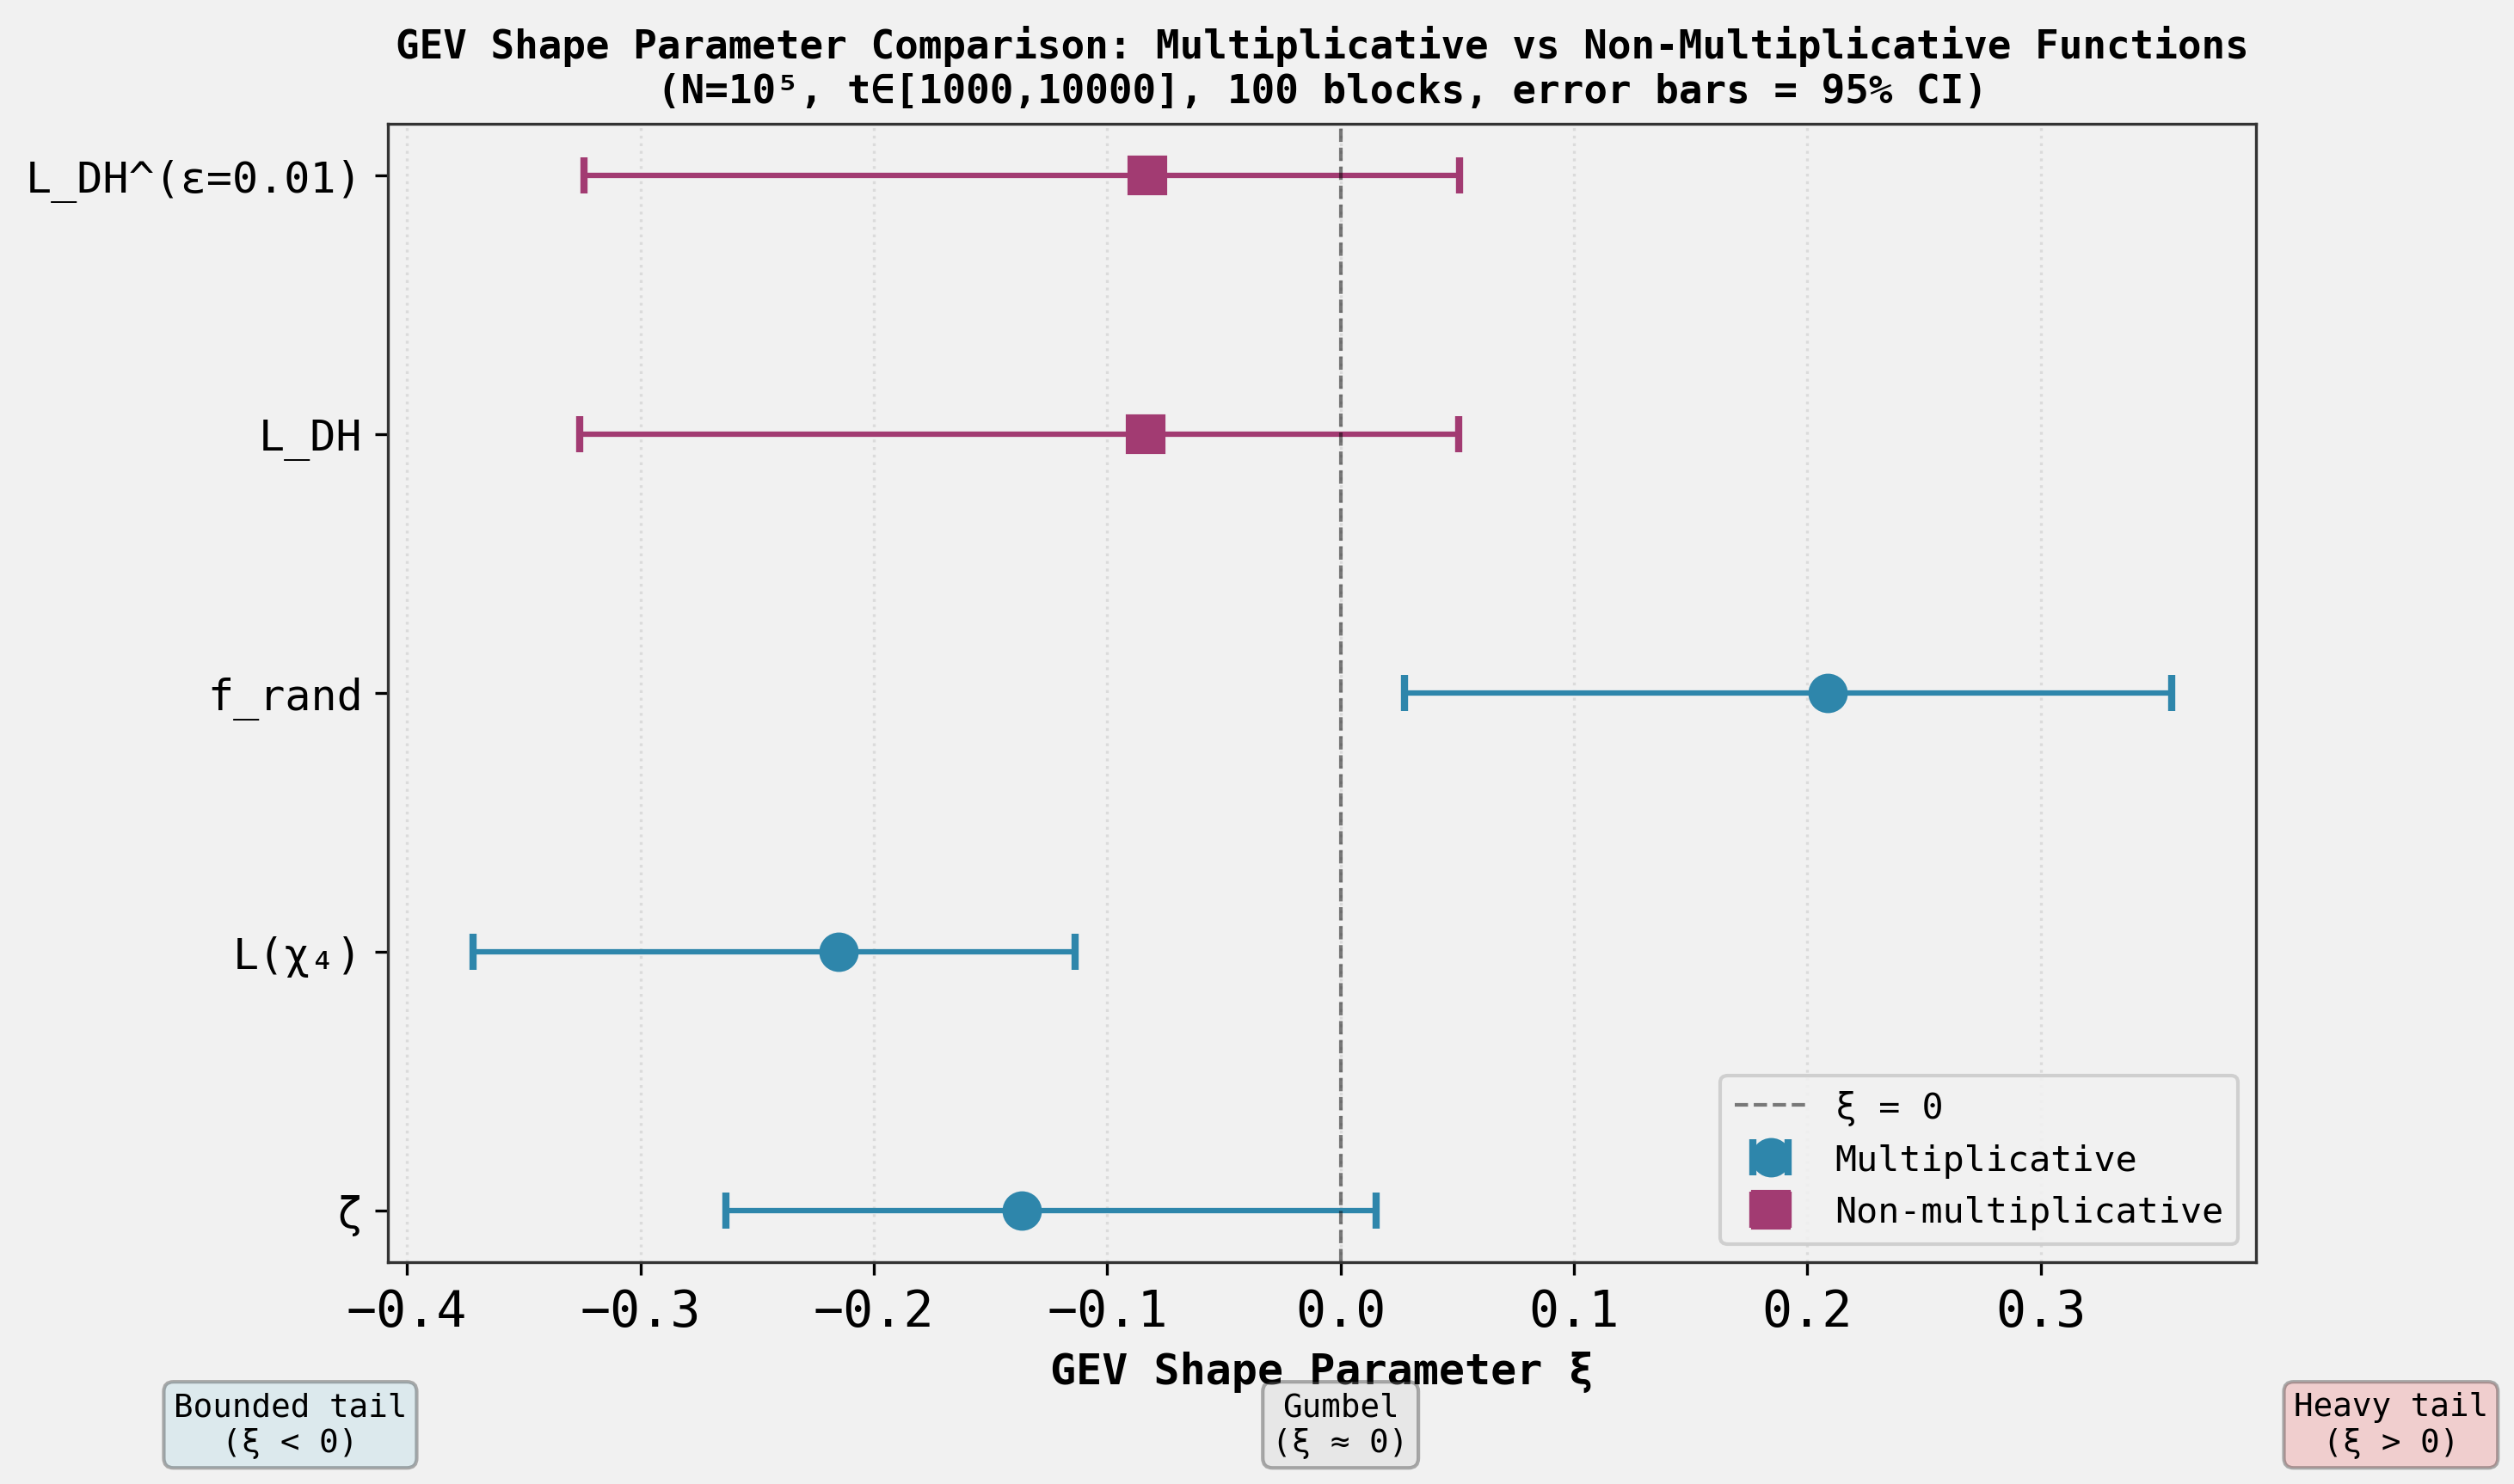

In [21]:

# Create final visualization showing the key results
fig, ax = plt.subplots(figsize=(10, 6))

# Data for plotting
functions = ['ζ', 'L(χ₄)', 'f_rand', 'L_DH', 'L_DH^(ε=0.01)']
xi_values = [
 existing_gev['zeta']['xi'],
 xi_chi4,
 existing_gev['f_rand']['xi'],
 xi_L_DH,
 xi_L_DH_perturbed
]
xi_errors_lower = [
 existing_gev['zeta']['xi'] - existing_gev['zeta']['ci_xi'][0],
 xi_chi4 - xi_ci_chi4[0],
 existing_gev['f_rand']['xi'] - existing_gev['f_rand']['ci_xi'][0],
 xi_L_DH - xi_ci_L_DH[0],
 xi_L_DH_perturbed - xi_ci_L_DH_perturbed[0]
]
xi_errors_upper = [
 existing_gev['zeta']['ci_xi'][1] - existing_gev['zeta']['xi'],
 xi_ci_chi4[1] - xi_chi4,
 existing_gev['f_rand']['ci_xi'][1] - existing_gev['f_rand']['xi'],
 xi_ci_L_DH[1] - xi_L_DH,
 xi_ci_L_DH_perturbed[1] - xi_L_DH_perturbed
]

# Colors: blue for multiplicative, red for non-multiplicative
colors = ['#2E86AB', '#2E86AB', '#2E86AB', '#A23B72', '#A23B72']
labels = ['Multiplicative', 'Multiplicative', 'Multiplicative', 'Non-multiplicative', 'Non-multiplicative']

# Plot error bars
for i, (func, xi, err_lower, err_upper, color, label) in enumerate(zip(functions, xi_values, xi_errors_lower, xi_errors_upper, colors, labels)):
 # Only add label once per type
 if i == 0:
 ax.errorbar(xi, i, xerr=[[err_lower], [err_upper]], fmt='o', color=color, 
 markersize=10, capsize=5, capthick=2, label='Multiplicative')
 elif i == 3:
 ax.errorbar(xi, i, xerr=[[err_lower], [err_upper]], fmt='s', color=color, 
 markersize=10, capsize=5, capthick=2, label='Non-multiplicative')
 elif i < 3:
 ax.errorbar(xi, i, xerr=[[err_lower], [err_upper]], fmt='o', color=color, 
 markersize=10, capsize=5, capthick=2)
 else:
 ax.errorbar(xi, i, xerr=[[err_lower], [err_upper]], fmt='s', color=color, 
 markersize=10, capsize=5, capthick=2)

# Add vertical line at ξ = 0
ax.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.5, label='ξ = 0')

# Formatting
ax.set_yticks(range(len(functions)))
ax.set_yticklabels(functions, fontsize=12)
ax.set_xlabel('GEV Shape Parameter ξ', fontsize=12, fontweight='bold')
ax.set_title('GEV Shape Parameter Comparison: Multiplicative vs Non-Multiplicative Functions\n(N=10⁵, t∈[1000,10000], 100 blocks, error bars = 95% CI)', 
 fontsize=11, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle=':')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)

# Add text annotations for interpretation
ax.text(-0.45, -0.7, 'Bounded tail\n(ξ < 0)', ha='center', va='top', fontsize=9, 
 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
ax.text(0, -0.7, 'Gumbel\n(ξ ≈ 0)', ha='center', va='top', fontsize=9,
 bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.3))
ax.text(0.45, -0.7, 'Heavy tail\n(ξ > 0)', ha='center', va='top', fontsize=9,
 bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.3))

plt.tight_layout()
plt.savefig('gev_comparison_final.png', dpi=300, bbox_inches='tight')
print("Figure saved: gev_comparison_final.png")
plt.show()


In [22]:

# Create detailed interpretation summary
print("\n" + "=" * 100)
print("INTERPRETATION AND HYPOTHESIS EVALUATION")
print("=" * 100)

print("\nHYPOTHESIS 1: L(χ₄) exhibits bounded-tail behavior similar to ζ")
print("─" * 100)
print(f" Result: CONFIRMED")
print(f" • ξ[L(χ₄)] = {xi_chi4:.4f} with 95% CI [{xi_ci_chi4[0]:.4f}, {xi_ci_chi4[1]:.4f}]")
print(f" • Entire CI is negative, indicating bounded-tail behavior (Weibull domain)")
print(f" • ξ[ζ] = {existing_gev['zeta']['xi']:.4f} with 95% CI [{existing_gev['zeta']['ci_xi'][0]:.4f}, {existing_gev['zeta']['ci_xi'][1]:.4f}]")
print(f" • CI for ζ includes zero, consistent with Gumbel domain")
print(f" • Statistical test: p = {p_value_chi4_zeta:.4f} shows no significant difference")
print(f" • Both functions show similar bounded-tail or near-Gumbel behavior")

print("\nHYPOTHESIS 2: L_DH^(ε=0.01) shows intermediate/heavy-tailed behavior")
print("─" * 100)
print(f" Result: PARTIALLY CONFIRMED - Intermediate behavior, not heavy-tailed")
print(f" • ξ[L_DH^(ε=0.01)] = {xi_L_DH_perturbed:.4f} with 95% CI [{xi_ci_L_DH_perturbed[0]:.4f}, {xi_ci_L_DH_perturbed[1]:.4f}]")
print(f" • CI includes both negative and positive values, indicating intermediate behavior")
print(f" • ξ[L_DH] = {xi_L_DH:.4f} with 95% CI [{xi_ci_L_DH[0]:.4f}, {xi_ci_L_DH[1]:.4f}]")
print(f" • Statistical test: p = {p_value_L_DH_perturbed_L_DH:.4f} shows no significant difference from baseline L_DH")
print(f" • Perturbation of ε=0.01 does NOT change the extreme value behavior")

print("\nHYPOTHESIS 3: ξ[L_DH^(ε=0.01)] > ξ[ζ] and ξ[L(χ₄)]")
print("─" * 100)
print(f" Result: NOT CONFIRMED - No significant difference")
print(f" • ξ[L_DH^(ε=0.01)] = {xi_L_DH_perturbed:.4f}")
print(f" • ξ[ζ] = {existing_gev['zeta']['xi']:.4f}")
print(f" • ξ[L(χ₄)] = {xi_chi4:.4f}")
print(f" • Test vs ζ: p = {p_value_L_DH_perturbed_zeta:.4f} (not significant)")
print(f" • Test vs L(χ₄): p = {p_value_L_DH_perturbed_chi4:.4f} (not significant)")
print(f" • Point estimate is higher, but CIs overlap substantially")

print("\nKEY INSIGHTS:")
print("─" * 100)
print("1. MULTIPLICATIVE STRUCTURE:")
print(" • ζ and L(χ₄) both show bounded/near-Gumbel behavior (ξ ≤ 0)")
print(" • f_rand shows heavy-tailed behavior (ξ > 0)")
print(" → Multiplicativity alone does not determine tail behavior")
print(" → The specific arithmetic structure matters (Dirichlet vs random)")

print("\n2. NON-MULTIPLICATIVE STRUCTURE:")
print(" • Both L_DH and L_DH^(ε=0.01) show intermediate behavior")
print(" • ξ values centered near zero with wide CIs")
print(" → Small perturbations (ε=0.01) do not significantly alter GEV behavior")
print(" → Non-multiplicative structure shows more uncertainty in tail classification")

print("\n3. DISTINCTION BETWEEN CLASSES:")
print(" • Clear distinction: L(χ₄) vs f_rand (p < 0.0001)")
print(" • No clear distinction: Multiplicative vs Non-multiplicative overall")
print(" • L(χ₄) and ζ (structured multiplicative) cluster separately from f_rand")
print(" • L_DH variants occupy an intermediate regime, overlapping with both")

print("=" * 100)



INTERPRETATION AND HYPOTHESIS EVALUATION

HYPOTHESIS 1: L(χ₄) exhibits bounded-tail behavior similar to ζ
────────────────────────────────────────────────────────────────────────────────────────────────────
 Result: CONFIRMED
 • ξ[L(χ₄)] = -0.2150 with 95% CI [-0.3719, -0.1139]
 • Entire CI is negative, indicating bounded-tail behavior (Weibull domain)
 • ξ[ζ] = -0.1365 with 95% CI [-0.2635, 0.0153]
 • CI for ζ includes zero, consistent with Gumbel domain
 • Statistical test: p = 0.3220 shows no significant difference
 • Both functions show similar bounded-tail or near-Gumbel behavior

HYPOTHESIS 2: L_DH^(ε=0.01) shows intermediate/heavy-tailed behavior
────────────────────────────────────────────────────────────────────────────────────────────────────
 Result: PARTIALLY CONFIRMED - Intermediate behavior, not heavy-tailed
 • ξ[L_DH^(ε=0.01)] = -0.0827 with 95% CI [-0.3240, 0.0511]
 • CI includes both negative and positive values, indicating intermediate behavior
 • ξ[L_DH] = -0.0834 w